# Day 4 Project — Merchant Performance & Sales Risk Analysis

Purpose: To apply statistical concepts to real-world merchant sales data and understand seller performance, variability, distribution and business risk.

#### Project Description:
This project analyzes merchant sales performance using statistical methods such as mean, median, quartiles, IQR, variance, standard deviation, coefficient of variation, skewness, Z-scores and probability distributions. The analysis also examines relationships between sales and factors such as products listed, ratings and discounts to determine what patterns are associated with seller performance and risk.

**Goal**: Analyze active sellers using descriptive statistics, probability, distributions, outliers and relationships to identify high-performing sellers, unusual performance and sales risk and provide data-driven business insights.

### Level 1 - Dataset Overview

In [7]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Loading the dataset
df = pd.read_csv("Downloads/merchant-performance-risk-analysis.csv")
df.head()

,index,merchantid,listedproducts,totalunitssold,meanunitssoldperproduct,rating,merchantratingscount,meanproductprices,meanretailprices,averagediscount,meandiscount,meanproductratingscount,totalurgencycount,urgencytextrate
0,0,5357bcf2bb72c5504882e889,2,120000,60000.0,4.219,320031.0,9.00,20.0,54.0,54.0,8836.0,1.0,50.0
1,1,5708773c3c02161b3f8c7900,5,107100,21420.0,3.934,139223.0,7.76,34.2,61.0,61.0,4010.0,3.0,60.0
2,2,5417aada4ad3ab27e954b76c,2,100007,50004.0,4.053,108048.0,8.00,8.0,-1.0,-1.0,5531.0,NaN,NaN
3,3,570f3a713a698c14278bb51e,1,100000,100000.0,3.889,19248.0,5.67,19.0,71.0,71.0,18393.0,1.0,100.0
4,4,53082ea15aefb07dfe1f2a4f,1,100000,100000.0,4.036,366898.0,5.00,33.0,85.0,85.0,13789.0,NaN,NaN


In [11]:
# Rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 958
Number of columns: 14


In [13]:
# Column names
print("Column names:")
print(df.columns.tolist())

Column names:
['index', 'merchantid', 'listedproducts', 'totalunitssold', 'meanunitssoldperproduct', 'rating', 'merchantratingscount', 'meanproductprices', 'meanretailprices', 'averagediscount', 'meandiscount', 'meanproductratingscount', 'totalurgencycount', 'urgencytextrate']


In [15]:
# Data types
print("Data types:")
print(df.dtypes)

Data types:
index                        int64
merchantid                  object
listedproducts               int64
totalunitssold               int64
meanunitssoldperproduct    float64
rating                     float64
merchantratingscount       float64
meanproductprices          float64
meanretailprices           float64
averagediscount            float64
meandiscount               float64
meanproductratingscount    float64
totalurgencycount          float64
urgencytextrate            float64
dtype: object


In [17]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
index                        0
merchantid                   0
listedproducts               0
totalunitssold               0
meanunitssoldperproduct      0
rating                       0
merchantratingscount         0
meanproductprices            0
meanretailprices             0
averagediscount              0
meandiscount                 0
meanproductratingscount      0
totalurgencycount          567
urgencytextrate            567
dtype: int64


In [19]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [21]:
# Numerical and categorical variables
numerical_variables = df.select_dtypes(include=np.number).columns.tolist()
categorical_variables = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical variables:")
print(numerical_variables)

print("\nCategorical variables:")
print(categorical_variables)

Numerical variables:
['index', 'listedproducts', 'totalunitssold', 'meanunitssoldperproduct', 'rating', 'merchantratingscount', 'meanproductprices', 'meanretailprices', 'averagediscount', 'meandiscount', 'meanproductratingscount', 'totalurgencycount', 'urgencytextrate']

Categorical variables:
['merchantid']


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    958 non-null    int64  
 1   merchantid               958 non-null    object 
 2   listedproducts           958 non-null    int64  
 3   totalunitssold           958 non-null    int64  
 4   meanunitssoldperproduct  958 non-null    float64
 5   rating                   958 non-null    float64
 6   merchantratingscount     958 non-null    float64
 7   meanproductprices        958 non-null    float64
 8   meanretailprices         958 non-null    float64
 9   averagediscount          958 non-null    float64
 10  meandiscount             958 non-null    float64
 11  meanproductratingscount  958 non-null    float64
 12  totalurgencycount        391 non-null    float64
 13  urgencytextrate          391 non-null    float64
dtypes: float64(10), int64(3), 

In [25]:
# Population mean
population_mean = df["totalunitssold"].mean()
# Random sample of 100 sellers
sample = df.sample(n=100, random_state=42)
# Sample mean
sample_mean = sample["totalunitssold"].mean()
print("Population Mean:", population_mean)
print("Sample Mean:", sample_mean)

print("Difference:", abs(population_mean - sample_mean))

Population Mean: 7124.483298538622
Sample Mean: 6292.88
Difference: 831.6032985386219


In [27]:
# Mean
mean_sales = df["totalunitssold"].mean()
# Median
median_sales = df["totalunitssold"].median()
# Mode
mode_sales = df["totalunitssold"].mode()
print("Mean:", mean_sales)
print("Median:", median_sales)
print("Mode:")
print(mode_sales)

Mean: 7124.483298538622
Median: 1000.0
Mode:
0    100
Name: totalunitssold, dtype: int64


In [31]:
variables = [
    "totalunitssold",
    "listedproducts",
    "rating",
    "meanproductprices"]
summary = df[variables].agg(
    ["mean", "median", "min", "max"])
summary

,totalunitssold,listedproducts,rating,meanproductprices
mean,7124.483299,1.641962,4.043994,8.634906
median,1000.000000,1.000000,4.055500,8.000000
min,1.000000,1.000000,2.333000,1.000000
max,120000.000000,15.000000,5.000000,49.000000


### Level 1 Conclusion
The dataset contains 958 sellers with no duplicate records. Sales are highly uneven, with the mean (7,124) much higher than the median (1,000), indicating that a few high-performing sellers pull the average upward. Therefore, median is more representative of a typical seller.

### Level 2 — Spread, Quartiles & Percentiles

In [35]:
# Range of Total Units Sold
min_sales = df["totalunitssold"].min()
max_sales = df["totalunitssold"].max()
sales_range = max_sales - min_sales

print("Minimum units sold:", min_sales)
print("Maximum units sold:", max_sales)
print("Range:", sales_range)

Minimum units sold: 1
Maximum units sold: 120000
Range: 119999


In [37]:
# Seller with minimum sales
min_seller = df.loc[df["totalunitssold"].idxmin()]
# Seller with maximum sales
max_seller = df.loc[df["totalunitssold"].idxmax()]
print("Minimum-sales seller:")
print(min_seller[["merchantid", "totalunitssold"]])

print("\nMaximum-sales seller:")
print(max_seller[["merchantid", "totalunitssold"]])

Minimum-sales seller:
merchantid        5d417e7070327a2743021677
totalunitssold                           1
Name: 955, dtype: object

Maximum-sales seller:
merchantid        5357bcf2bb72c5504882e889
totalunitssold                      120000
Name: 0, dtype: object


In [39]:
# Quartiles
Q1 = df["totalunitssold"].quantile(0.25)
Q2 = df["totalunitssold"].quantile(0.50)
Q3 = df["totalunitssold"].quantile(0.75)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

Q1: 100.0
Q2: 1000.0
Q3: 10000.0


In [41]:
# Interquartile Range
IQR = Q3 - Q1
print("IQR:", IQR)

IQR: 9900.0


Interpretation: The middle 50% of sellers have sales spread across a range of 9900 units from 100 to 10000 units.

In [44]:
# Percentiles
percentiles = df["totalunitssold"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
print(percentiles)

0.10      100.0
0.25      100.0
0.50     1000.0
0.75    10000.0
0.90    20000.0
Name: totalunitssold, dtype: float64


### Level 2 - Spread, Quartiles & Percentiles Conclusion
Seller sales are highly dispersed: the middle 50% range from 100 to 10000 units, while the top 10% exceed 20000 units. This suggests a small group of high-performing sellers contributes disproportionately to overall sales.

### Level 3 - Variance, SD & Relative Variability

In [56]:
# Population Variance & Standard Deviation
sales = df["totalunitssold"]
population_variance = sales.var(ddof=0)
population_sd = sales.std(ddof=0)

print("Population Variance:", population_variance)
print("Population Standard Deviation:", population_sd)

Population Variance: 206095405.47727913
Population Standard Deviation: 14356.023316966266


Interpretation: The SD of 14356 units means seller sales have a very large spread around the population mean of 7124 units.

In [59]:
# Compare Absolute Variability
variables = [
    "totalunitssold",
    "listedproducts",
    "meanproductprices",
    "meanretailprices"]
sd_comparison = df[variables].std(ddof=0)
print("Population Standard Deviation:")
print(sd_comparison)

print("\nVariable with greatest absolute spread:")
print(sd_comparison.idxmax())

print("\nGreatest SD:")
print(sd_comparison.max())

Population Standard Deviation:
totalunitssold       14356.023317
listedproducts           1.245532
meanproductprices        3.985517
meanretailprices        30.242922
dtype: float64

Variable with greatest absolute spread:
totalunitssold

Greatest SD:
14356.023316966266


Interpretation: *totalunitssold* has the highest absolute variability, with an SD of 14356 units. However, SD cannot fairly compare variables measured on different scales. Therefore, we need Coefficient of Variation (CV) to compare relative variability.

In [64]:
# Coefficient of Variation
variables = [
    "totalunitssold",
    "listedproducts",
    "meanproductprices",
    "meanretailprices"]
means = df[variables].mean()
sds = df[variables].std(ddof=0)
cv = (sds / means) * 100
print("Coefficient of Variation (%):")
print(cv.sort_values(ascending=False))

print("\nHighest relative variability:")
print(cv.idxmax())

print("Highest CV:", cv.max(), "%")

Coefficient of Variation (%):
totalunitssold       201.502659
meanretailprices     121.936130
listedproducts        75.856300
meanproductprices     46.155887
dtype: float64

Highest relative variability:
totalunitssold
Highest CV: 201.50265942669813 %


Interpretation: Highest relative variability: totalunitssold

*totalunitssold* has a CV of 201.50%, meaning its standard deviation is more than twice its mean. This indicates extremely high relative variability in seller sales performance.

### Level 3 - Variance, SD & Relative Variability Conclusion

Seller sales show extremely high variability, with *totalunitssold* having the highest relative variability (CV = 201.50%). This suggests substantial differences in seller performance and potential sales risk.

### Level 4 - Distribution & Skewness

In [70]:
# Skewness
sales_skewness = df["totalunitssold"].skew()
print("Skewness:", sales_skewness)

if sales_skewness > 0.5:
    print("Distribution: Positively skewed")
elif sales_skewness < -0.5:
    print("Distribution: Negatively skewed")
else:
    print("Distribution: Approximately symmetric")

Skewness: 3.893552144007934
Distribution: Positively skewed


Interpretation: *totalunitssold* is strongly positively skewed, with a long right tail caused by a relatively small number of very high-performing sellers.

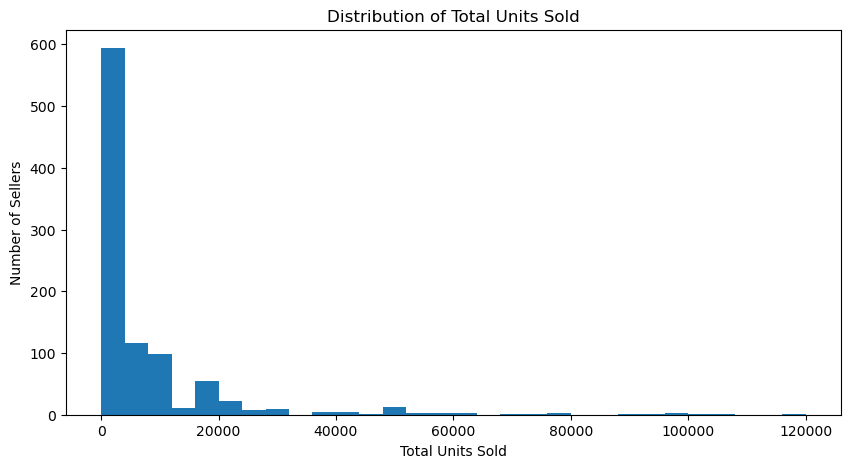

In [72]:
# Histogram of Total Units Sold
plt.figure(figsize=(10, 5))
plt.hist(df["totalunitssold"], bins=30)
plt.title("Distribution of Total Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("Number of Sellers")
plt.show()

Interpretation: The histogram shows that most sellers are concentrated at relatively low sales levels, while a small number of sellers extend far into the higher-sales range. The long right tail visually confirms that *totalunitssold* has a strongly positively skewed distribution.

In [80]:
# Mean vs Median vs Skewness
mean_sales = df["totalunitssold"].mean()
median_sales = df["totalunitssold"].median()
skewness = df["totalunitssold"].skew()

print("Mean:", mean_sales)
print("Median:", median_sales)
print("Skewness:", skewness)

print("\nMean > Median:", mean_sales > median_sales)

Mean: 7124.483298538622
Median: 1000.0
Skewness: 3.893552144007934

Mean > Median: True


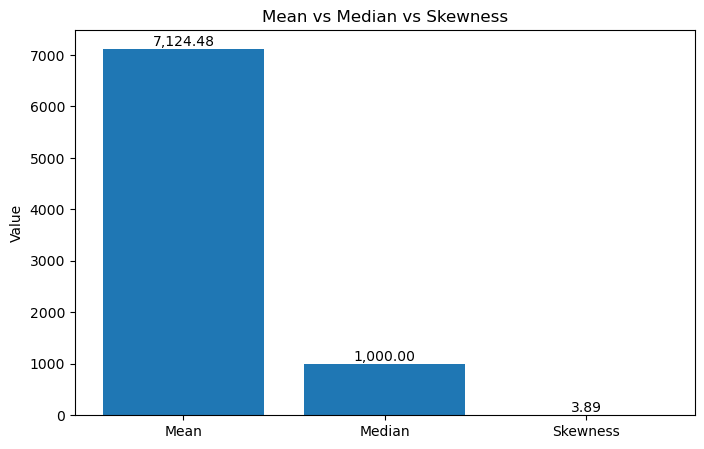

In [88]:
# Mean vs Median vs Skewness
mean_sales = df["totalunitssold"].mean()
median_sales = df["totalunitssold"].median()
skewness = df["totalunitssold"].skew()
# Create normalized values for comparison
values = [mean_sales, median_sales, skewness]
labels = ["Mean", "Median", "Skewness"]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Mean vs Median vs Skewness")
plt.ylabel("Value")

for i, value in enumerate(values):
    plt.text(i, value, f"{value:,.2f}", ha="center", va="bottom")
plt.show()

Interpretation: The mean (7124) is substantially higher than the median (1000), while skewness is strongly positive (3.89). The histogram also shows a long right tail. Therefore, the mean, median, skewness and histogram all consistently indicate that seller sales are strongly right-skewed.

### Level 4 - Distribution & Skewness Conclusion
Seller sales are strongly right-skewed, with most sellers having relatively low sales and a small number of exceptionally high-performing sellers. The mean is therefore much less representative of a typical seller than the median.

### Level 5 - Outliers & Z-Scores

In [90]:
# IQR Outlier Detection
Q1 = df["totalunitssold"].quantile(0.25)
Q3 = df["totalunitssold"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers
outliers = df[
    (df["totalunitssold"] < lower_bound) |
    (df["totalunitssold"] > upper_bound)]
number_of_outliers = len(outliers)
percentage_outliers = (number_of_outliers / len(df)) * 100

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", number_of_outliers)
print("Percentage of Outliers:", percentage_outliers)

Q1: 100.0
Q3: 10000.0
IQR: 9900.0
Lower Bound: -14750.0
Upper Bound: 24850.0
Number of Outliers: 61
Percentage of Outliers: 6.367432150313153


Interpretation: The IQR method identifies 61 sellers (6.37%) as high-sales outliers, with sales above 24850 units. These sellers are unusually high performers compared with the middle 50% of merchants. They should not automatically be treated as errors because they may represent genuinely successful sellers.

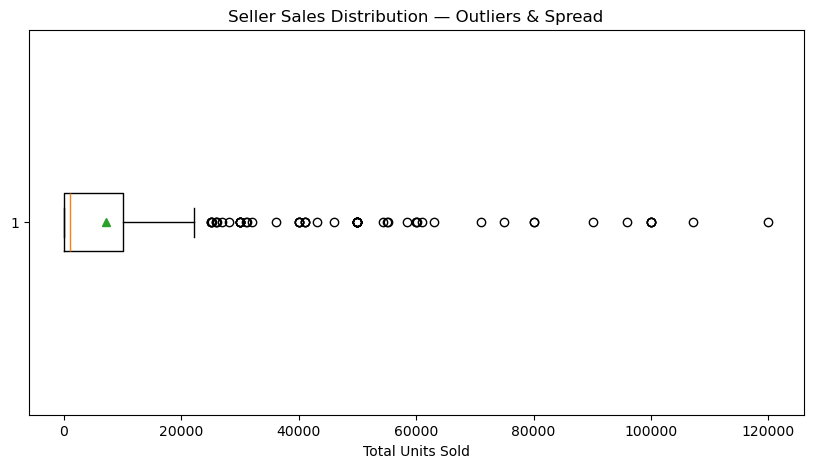

In [94]:
# Outlier Visualization
plt.figure(figsize=(10, 5))
plt.boxplot(
    df["totalunitssold"],
    vert=False,
    showmeans=True)
plt.title("Seller Sales Distribution — Outliers & Spread")
plt.xlabel("Total Units Sold")
plt.show()

Interpretation: The boxplot shows that most sellers are concentrated at relatively low sales levels, while a smaller group of sellers lies far above the upper boundary. This visually confirms the strong right-skewness and the presence of unusually high-performing sellers.

In [98]:
# Investigate Outlier Sellers
outlier_sellers = df[
    df["totalunitssold"] > upper_bound
].copy()
outlier_variables = [
    "totalunitssold",
    "listedproducts",
    "rating",
    "merchantratingscount",
    "meanproductprices",
    "meanretailprices",
    "averagediscount"]
outlier_summary = outlier_sellers[outlier_variables].describe()

outlier_summary

,totalunitssold,listedproducts,rating,merchantratingscount,meanproductprices,meanretailprices,averagediscount
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,51844.475410,3.672131,4.075705,88256.540984,7.708197,21.912623,22.295082
std,24096.444075,2.693952,0.124355,132805.720964,2.584828,26.502110,36.997002
min,25000.000000,1.000000,3.802000,5816.000000,2.000000,2.000000,-16.000000
25%,31000.000000,2.000000,3.999000,17816.000000,5.770000,6.000000,-8.000000
50%,50000.000000,3.000000,4.090000,43676.000000,7.760000,8.750000,1.000000
75%,60000.000000,4.000000,4.154000,88193.000000,9.000000,22.000000,55.000000
max,120000.000000,15.000000,4.387000,839882.000000,16.330000,114.000000,91.000000


In [100]:
# Compare Outlier Sellers with the Full Dataset
comparison = pd.DataFrame({
    "All Sellers": df[outlier_variables].mean(),
    "Outlier Sellers": outlier_sellers[outlier_variables].mean()})

comparison

,All Sellers,Outlier Sellers
totalunitssold,7124.483299,51844.475410
listedproducts,1.641962,3.672131
rating,4.043994,4.075705
merchantratingscount,22020.446764,88256.540984
meanproductprices,8.634906,7.708197
meanretailprices,24.802265,21.912623
averagediscount,28.721294,22.295082


Interpretation: The 61 sales outliers appear more likely to represent genuinely high-performing sellers rather than obvious data errors. Their higher sales are accompanied by stronger merchant engagement and slightly higher ratings. Therefore, they should not be automatically removed from the analysis.

In [103]:
# Z-Scores
mean_sales = df["totalunitssold"].mean()
sd_sales = df["totalunitssold"].std(ddof=0)
df["z_score"] = (
    (df["totalunitssold"] - mean_sales) / sd_sales)
# Highest and lowest Z-score
highest_z = df["z_score"].max()
lowest_z = df["z_score"].min()

print("Highest Z-score:", highest_z)
print("Lowest Z-score:", lowest_z)
# Count sellers beyond thresholds
above_2 = (df["z_score"].abs() > 2).sum()
above_3 = (df["z_score"].abs() > 3).sum()

print("Sellers with |Z| > 2:", above_2)
print("Sellers with |Z| > 3:", above_3)

Highest Z-score: 7.862589396052499
Lowest Z-score: -0.4962017085971107
Sellers with |Z| > 2: 43
Sellers with |Z| > 3: 21


In [105]:
# Sellers with |Z| > 2
z_above_2 = df[df["z_score"].abs() > 2]
# Sellers with |Z| > 3
z_above_3 = df[df["z_score"].abs() > 3]
print("Sellers with |Z| > 2:")
print(z_above_2[["merchantid", "totalunitssold", "z_score"]])

print("\nSellers with |Z| > 3:")
print(z_above_3[["merchantid", "totalunitssold", "z_score"]])

Sellers with |Z| > 2:
                  merchantid  totalunitssold   z_score
0   5357bcf2bb72c5504882e889          120000  7.862589
1   5708773c3c02161b3f8c7900          107100  6.964012
2   5417aada4ad3ab27e954b76c          100007  6.469934
3   570f3a713a698c14278bb51e          100000  6.469446
4   53082ea15aefb07dfe1f2a4f          100000  6.469446
5   53f2beb39020ee03566d6e18          100000  6.469446
6   5926c5ace8ff5525241b368d           96000  6.190817
7   5860c757b1e41d4d67d183e8           90100  5.779840
8   52bd3ddb34067e4620a4c62d           80000  5.076302
9   5a7b23a69bda4e3d375e7b3f           80000  5.076302
10  53a2a09ad91139519161a267           75000  4.728017
11  539937d634067e06707b1a8e           71100  4.456354
12  58ad449708de0c6dc59d9e06           63100  3.899096
13  56e43d9e3a698c3826a5feff           61000  3.752816
14  53aa664438d3046ee44a5024           60100  3.690125
15  53facca81c105e3d5866e212           60000  3.683159
16  5384613a796f680f9d78a127           6000

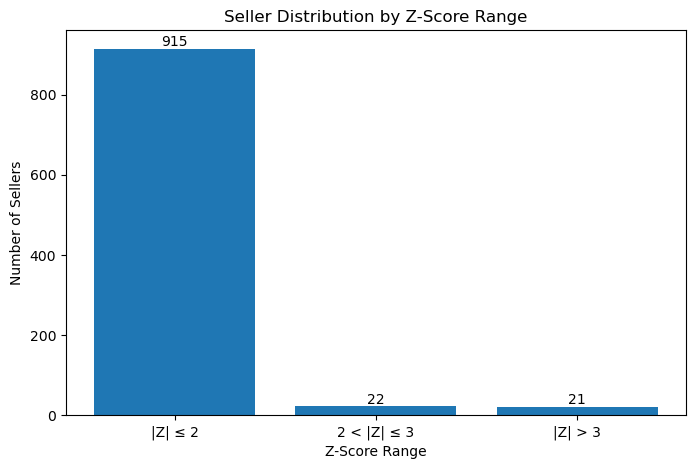

In [107]:
# Z-Score Threshold Visualization
z_categories = {
    "|Z| ≤ 2": (df["z_score"].abs() <= 2).sum(),
    "2 < |Z| ≤ 3": (
        (df["z_score"].abs() > 2) &
        (df["z_score"].abs() <= 3)
    ).sum(),
    "|Z| > 3": (df["z_score"].abs() > 3).sum()}
plt.figure(figsize=(8, 5))
plt.bar(
    z_categories.keys(),
    z_categories.values())
plt.title("Seller Distribution by Z-Score Range")
plt.xlabel("Z-Score Range")
plt.ylabel("Number of Sellers")
for i, value in enumerate(z_categories.values()):
    plt.text(i, value, str(value), ha="center", va="bottom")
plt.show()

Interpretation: Z-score analysis confirms that seller sales contain unusually high performers. 43 sellers are more than 2 standard deviations from the mean, including 21 sellers beyond 3 standard deviations. The maximum Z-score of 7.86 indicates an exceptionally high sales performer, while the absence of strongly negative Z-scores shows that extreme sales behavior is concentrated on the upper end.

In [110]:
# Highest Z-Score Seller
extreme_seller = df.loc[df["z_score"].idxmax()]

print("Seller ID:", extreme_seller["merchantid"])
print("Units Sold:", extreme_seller["totalunitssold"])
print("Dataset Mean:", mean_sales)
print("Standard Deviation:", sd_sales)
print("Z-Score:", extreme_seller["z_score"])

Seller ID: 5357bcf2bb72c5504882e889
Units Sold: 120000
Dataset Mean: 7124.483298538622
Standard Deviation: 14356.023316966266
Z-Score: 7.862589396052499


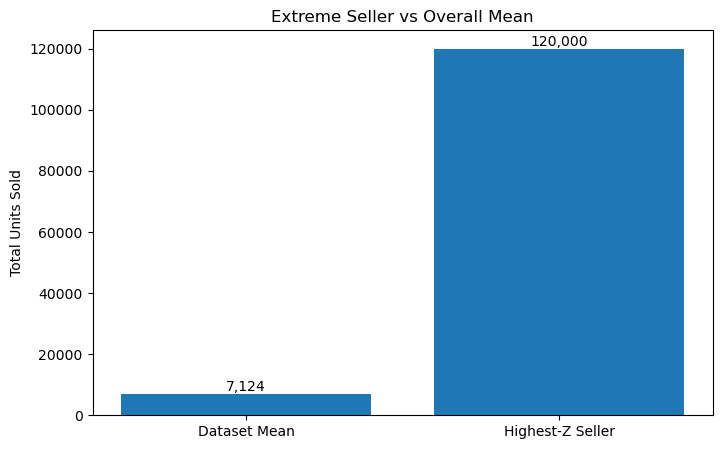

In [112]:
# Extreme Seller vs Overall Mean
plt.figure(figsize=(8, 5))
values = [
    mean_sales,
    extreme_seller["totalunitssold"]]
labels = [
    "Dataset Mean",
    "Highest-Z Seller"]
plt.bar(labels, values)
plt.title("Extreme Seller vs Overall Mean")
plt.ylabel("Total Units Sold")

for i, value in enumerate(values):
    plt.text(i, value, f"{value:,.0f}", ha="center", va="bottom")
plt.show()

Interpretation: The seller sold 120000 units, compared with the overall average of 7124 units.

### Level 5 - Outliers & Z-Scores Conclusion 
Outlier and Z-score analysis identified a small group of exceptionally high-performing sellers. These sellers contribute substantially to the high overall sales mean and should be investigated as potential sources of business opportunity rather than automatically treated as data errors.

### Level 6 - Normal Distribution

In [119]:
# 68–95–99.7 Rule
mean_sales = df["totalunitssold"].mean()
sd_sales = df["totalunitssold"].std(ddof=0)

range_68 = (mean_sales - sd_sales, mean_sales + sd_sales)
range_95 = (mean_sales - 2 * sd_sales, mean_sales + 2 * sd_sales)
range_997 = (mean_sales - 3 * sd_sales, mean_sales + 3 * sd_sales)

print("68% range (μ ± 1σ):", range_68)
print("95% range (μ ± 2σ):", range_95)
print("99.7% range (μ ± 3σ):", range_997)

68% range (μ ± 1σ): (-7231.540018427644, 21480.506615504888)
95% range (μ ± 2σ): (-21587.563335393912, 35836.52993247115)
99.7% range (μ ± 3σ): (-35943.58665236017, 50192.55324943742)


Interpretation: Under the normal-distribution assumption, approximately 68%, 95% and 99.7% of sellers would theoretically fall within 1, 2 and 3 standard deviations of the mean. However, the resulting negative lower bounds are impossible for units sold, suggesting that the normal distribution is not a good fit for this sales data.

In [122]:
# Normality Assessment
mean_sales = df["totalunitssold"].mean()
median_sales = df["totalunitssold"].median()
skewness = df["totalunitssold"].skew()

outlier_count = len(
    df[
        (df["totalunitssold"] < lower_bound) |
        (df["totalunitssold"] > upper_bound)])
z3_count = (df["z_score"].abs() > 3).sum()

print("Mean:", mean_sales)
print("Median:", median_sales)
print("Skewness:", skewness)
print("IQR Outliers:", outlier_count)
print("|Z| > 3:", z3_count)
print("Maximum:", df["totalunitssold"].max())

Mean: 7124.483298538622
Median: 1000.0
Skewness: 3.893552144007934
IQR Outliers: 61
|Z| > 3: 21
Maximum: 120000


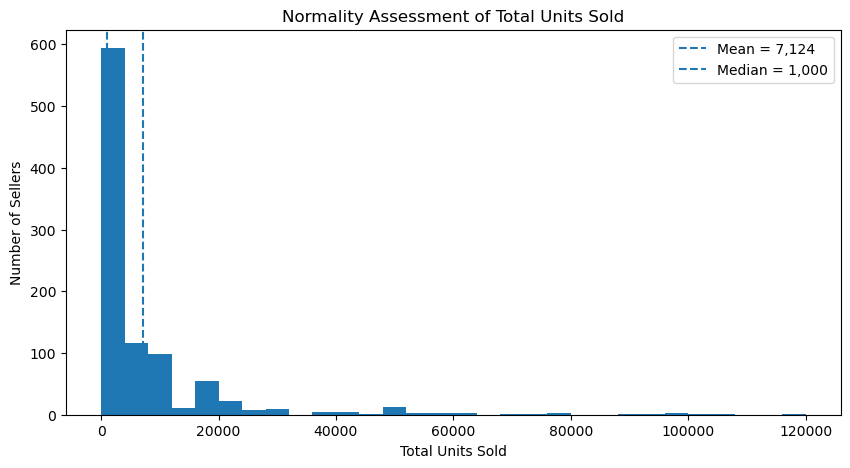

In [124]:
# Normality Assessment
mean_sales = df["totalunitssold"].mean()
median_sales = df["totalunitssold"].median()

plt.figure(figsize=(10, 5))
plt.hist(df["totalunitssold"], bins=30)
plt.axvline(
    mean_sales,
    linestyle="--",
    label=f"Mean = {mean_sales:,.0f}")
plt.axvline(
    median_sales,
    linestyle="--",
    label=f"Median = {median_sales:,.0f}")
plt.title("Normality Assessment of Total Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("Number of Sellers")
plt.legend()
plt.show()

Interpretation: The histogram shows a strongly right-skewed distribution rather than a symmetric bell-shaped distribution. The large gap between the mean and median, skewness of 3.89, 61 IQR outliers and 21 sellers with |Z| > 3 all indicate that totalunitssold is not normally distributed.

### Level 6 Conclusion - Normal Distribution
*totalunitssold* is not normally distributed. The mean (7124) is much higher than the median (1000), skewness is strongly positive (3.89), and there are 61 IQR outliers and 21 sellers with |Z| > 3. The maximum sales of 120,000 units further confirms the presence of extreme high performers and a strong right tail.

### Level 7 - Probability Distributions

In [131]:
# Bernoulli Distribution
q75 = df["totalunitssold"].quantile(0.75)
df["high_performer"] = df["totalunitssold"] > q75
print("75th Percentile:", q75)

print("\nHigh Performer:", df["high_performer"].sum())
print("Not High Performer:", (~df["high_performer"]).sum())

print("\nProbability of High Performer:",
      df["high_performer"].mean())

print("Probability of Not High Performer:",
      1 - df["high_performer"].mean())

75th Percentile: 10000.0

High Performer: 166
Not High Performer: 792

Probability of High Performer: 0.1732776617954071
Probability of Not High Performer: 0.826722338204593


Interpretation: Sellers above the 75th-percentile sales threshold are classified as high performers. Due to tied values at the percentile boundary, the resulting group contains 17.33% of sellers.

In [134]:
# Binomial Distribution
from math import comb
n = 10
k = 3
p = 0.25
probability = (
    comb(n, k)
    * (p ** k)
    * ((1 - p) ** (n - k)))
print("Probability of exactly 3 high performers:", probability)
print("Probability (%):", probability * 100)

Probability of exactly 3 high performers: 0.25028228759765625
Probability (%): 25.028228759765625


Interpretation: Assuming a 25% high-performer probability, there is a 25.03% chance that exactly 3 out of 10 randomly selected sellers will be high performers.

In [137]:
# Inspect totalurgencycount
urgency = df["totalurgencycount"].dropna()
print("Mean:", urgency.mean())
print("Variance:", urgency.var())
print("Minimum:", urgency.min())
print("Maximum:", urgency.max())
print("Number of observations:", urgency.count())

Mean: 1.2097186700767264
Variance: 0.34052068988129824
Minimum: 1.0
Maximum: 6.0
Number of observations: 391


Interpretation: Although totalurgencycount is count data, a Poisson distribution is not a good fit because its mean (1.21) is substantially different from its variance (0.34). The Poisson assumption generally requires the mean and variance to be approximately equal.

### Level 7 - Probability Distributions Conclusion
The Bernoulli and Binomial analyses provide useful probability models for seller performance, while totalurgencycount does not appear to satisfy the key mean-variance condition required for a Poisson distribution.

### Level 8 - Business Relationships

In [142]:
# Products vs Sales
correlation = df["listedproducts"].corr(df["totalunitssold"])
print("Correlation between Listed Products and Total Units Sold:",
      correlation)

Correlation between Listed Products and Total Units Sold: 0.3833732392170073


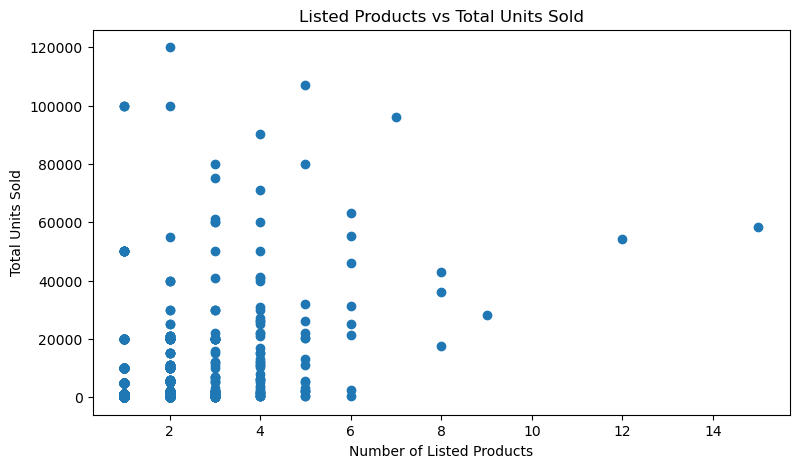

In [144]:
# Scatter plot — Listed Products vs Total Units Sold
plt.figure(figsize=(9, 5))
plt.scatter(
    df["listedproducts"],
    df["totalunitssold"])
plt.title("Listed Products vs Total Units Sold")
plt.xlabel("Number of Listed Products")
plt.ylabel("Total Units Sold")
plt.show()

Interpretation: There is a weak-to-moderate positive relationship between the number of listed products and total units sold, suggesting that sellers with more products tend to sell more units, but the relationship is not very strong.

In [147]:
# Rating vs Sales
correlation_rating = df["rating"].corr(df["totalunitssold"])
print("Correlation between Rating and Total Units Sold:",
      correlation_rating)

Correlation between Rating and Total Units Sold: 0.09483348131116129


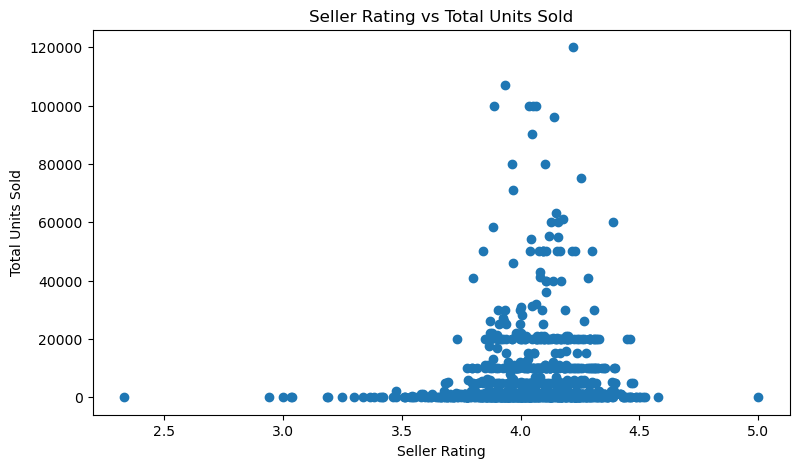

In [149]:
# Scatter Plot — Rating vs Total Units Sold
plt.figure(figsize=(9, 5))
plt.scatter(
    df["rating"],
    df["totalunitssold"])
plt.title("Seller Rating vs Total Units Sold")
plt.xlabel("Seller Rating")
plt.ylabel("Total Units Sold")
plt.show()

Interpretation: The correlation of 0.095 indicates a very weak positive relationship, suggesting that seller rating has little to no meaningful linear association with total units sold.

In [152]:
# Discount vs Sales
correlation_discount = df["meandiscount"].corr(df["totalunitssold"])
print("Correlation between Discount and Total Units Sold:",
      correlation_discount)

Correlation between Discount and Total Units Sold: -0.02789509184183358


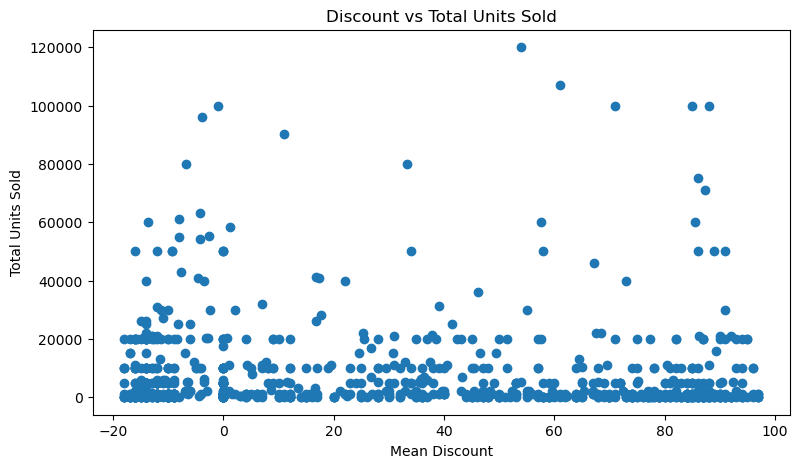

In [154]:
# Scatter Plot — Discount vs Total Units Sold
plt.figure(figsize=(9, 5))
plt.scatter(
    df["meandiscount"],
    df["totalunitssold"])
plt.title("Discount vs Total Units Sold")
plt.xlabel("Mean Discount")
plt.ylabel("Total Units Sold")
plt.show()

Interpretation: The correlation of −0.028 indicates an almost nonexistent negative relationship, suggesting that discount levels have virtually no linear association with total units sold.

### Level 8 Conclusion - Business Relationships
Seller product count has a weak-to-moderate positive relationship with sales (r = 0.383), while seller rating has a very weak positive relationship (r = 0.095) and discount has an almost nonexistent negative relationship (r = −0.028) with sales. Overall, listed products show the strongest association with sales, but none of these correlations indicate causation.

### Level 9 - Seller Performance & Risk

In [246]:
# Create Performance Groups
q25 = df["totalunitssold"].quantile(0.25)
q75 = df["totalunitssold"].quantile(0.75)

print("Performance Group Definitions")
print("=============================")
print(f"Low Performer    : Sales <= {q25:,.0f}")
print(f"Medium Performer : {q25:,.0f} < Sales <= {q75:,.0f}")
print(f"High Performer   : Sales > {q75:,.0f}")

df["performance_group"] = pd.cut(
    df["totalunitssold"],
    bins=[-float("inf"), q25, q75, float("inf")],
    labels=["Low Performer", "Medium Performer", "High Performer"],
    include_lowest=True)
performance_summary = df.groupby(
    "performance_group",
    observed=True
)["totalunitssold"].agg(
    Mean="mean",
    Median="median",
    SD=lambda x: x.std(ddof=0),
    Count="count")
performance_summary["CV (%)"] = (
    performance_summary["SD"] /
    performance_summary["Mean"]) * 100

performance_summary

Performance Group Definitions
Low Performer    : Sales <= 100
Medium Performer : 100 < Sales <= 10,000
High Performer   : Sales > 10,000


,Mean,Median,SD,Count,CV (%)
performance_group,,,,,
Low Performer,81.964567,100.0,33.461029,254,40.823774
Medium Performer,3249.355019,1075.0,3349.092921,538,103.069468
High Performer,30459.536145,20010.0,21999.039216,166,72.223816


Interpretation: High performers have the highest average sales (30460) and median (20010), while medium performers have the highest relative variability (CV = 103.07%). Low performers are the most consistent (CV = 40.82%), whereas high performers show strong sales with moderately high variability (CV = 72.22%).

In [239]:
# Performance vs Risk
print("Performance vs Risk")
print("===================")
print(performance_summary)

Performance vs Risk
                           Mean   Median            SD  Count      CV (%)
performance_group                                                        
Low Performer         81.964567    100.0     33.461029    254   40.823774
Medium Performer    3249.355019   1075.0   3349.092921    538  103.069468
High Performer     30459.536145  20010.0  21999.039216    166   72.223816


<Figure size 1000x600 with 0 Axes>

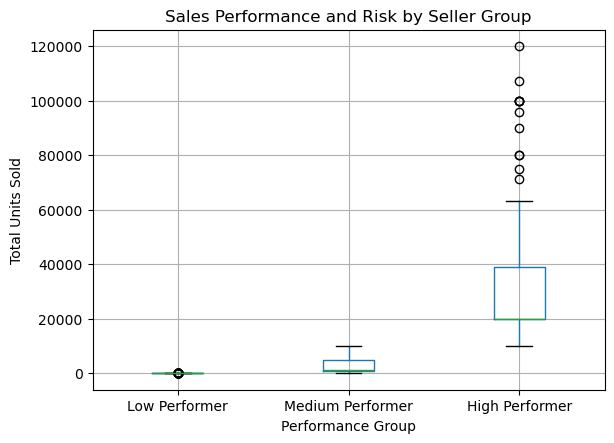

In [243]:
# Performance vs Risk - Visualize it
plt.figure(figsize=(10, 6))
df.boxplot(
    column="totalunitssold",
    by="performance_group")
plt.title("Sales Performance and Risk by Seller Group")
plt.suptitle("")
plt.xlabel("Performance Group")
plt.ylabel("Total Units Sold")
plt.show()

Performance vs Risk Interpretation: High performers have the highest sales performance, while medium performers have the greatest relative risk (CV = 103.07%). Low performers are the most consistent (CV = 40.82%), whereas high performers combine strong sales with moderate relative variability (CV = 72.22%).

In [165]:
# Top 10 Sellers
top_10 = df.nlargest(10, "totalunitssold")
top_10[["merchantid",
        "totalunitssold",
        "rating",
        "listedproducts",
        "meanproductprices",
        "meandiscount",
        "merchantratingscount"]]

,merchantid,totalunitssold,rating,listedproducts,meanproductprices,meandiscount,merchantratingscount
0,5357bcf2bb72c5504882e889,120000,4.219,2,9.00,54.00,320031.0
1,5708773c3c02161b3f8c7900,107100,3.934,5,7.76,61.00,139223.0
2,5417aada4ad3ab27e954b76c,100007,4.053,2,8.00,-1.00,108048.0
3,570f3a713a698c14278bb51e,100000,3.889,1,5.67,71.00,19248.0
4,53082ea15aefb07dfe1f2a4f,100000,4.036,1,5.00,85.00,366898.0
5,53f2beb39020ee03566d6e18,100000,4.067,1,5.77,88.00,330405.0
6,5926c5ace8ff5525241b368d,96000,4.139,7,6.69,-3.86,55499.0
7,5860c757b1e41d4d67d183e8,90100,4.049,4,3.43,11.00,151249.0
8,52bd3ddb34067e4620a4c62d,80000,4.104,3,7.22,33.33,839882.0
9,5a7b23a69bda4e3d375e7b3f,80000,3.966,5,8.40,-6.80,12974.0


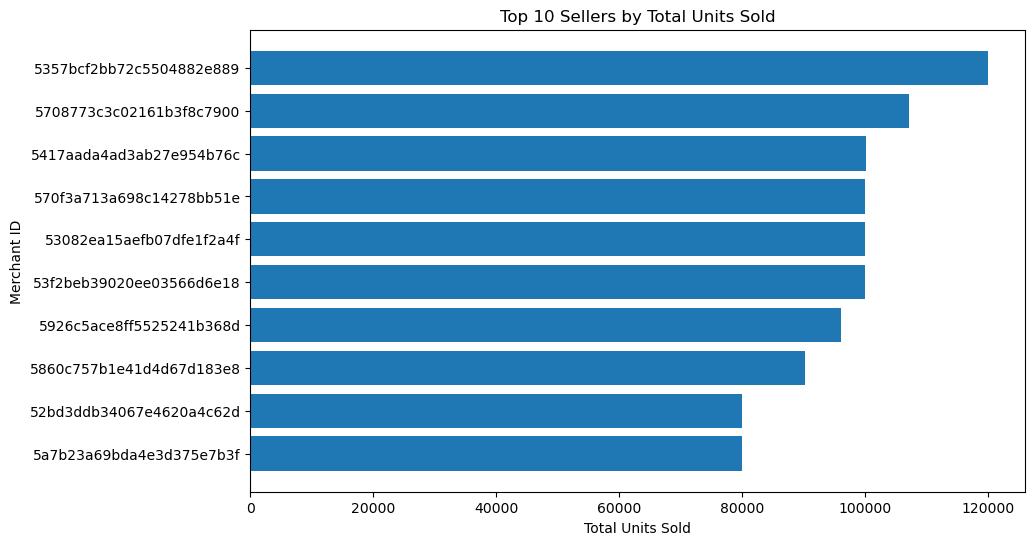

In [167]:
# Top 10 Sellers — Horizontal Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(
    top_10["merchantid"],
    top_10["totalunitssold"])
plt.title("Top 10 Sellers by Total Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("Merchant ID")
plt.gca().invert_yaxis()
plt.show()

In [169]:
# Top 10 Sellers — Average Characteristics
top_10[["rating",
        "listedproducts",
        "meanproductprices",
        "meandiscount",
        "merchantratingscount"]].mean()

rating                       4.0456
listedproducts               3.1000
meanproductprices            6.6940
meandiscount                39.1670
merchantratingscount    234345.7000
dtype: float64

Top 10 Sellers Interpretation: The top sellers show varied product counts and discount levels, suggesting that no single discount or product-count pattern characterizes all high-performing sellers.

### Level 9 - Seller Performance & Risk Conclusion
The strongest sellers achieve exceptionally high sales, but their characteristics vary considerably. Sales performance appears to be influenced by multiple factors rather than a single variable such as rating, product count or discount.

### Level 10 - Final Business Analysis

In [175]:
# High Performance, Low Risk
high_low_risk = performance_summary[
    (performance_summary["Mean"] == performance_summary["Mean"].max()) &
    (performance_summary["CV (%)"] < performance_summary["CV (%)"].median())]
high_low_risk

,Mean,Median,SD,Count,CV (%)
performance_group,,,,,


In [177]:
# Compare performance groups by sales and relative risk
risk_analysis = performance_summary[
    ["Mean", "Median", "SD", "CV (%)"]
].copy()
risk_analysis

,Mean,Median,SD,CV (%)
performance_group,,,,
Low Performer,81.964567,100.0,33.461029,40.823774
Medium Performer,3249.355019,1075.0,3349.092921,103.069468
High Performer,30459.536145,20010.0,21999.039216,72.223816


Interpretation: High performers are the strongest overall group, with the highest average sales (30,459.54) and lower relative variability (CV = 72.22%) than medium performers (103.07%), making them comparatively strong and stable performers.

In [180]:
# High Performance, High Risk
high_performers = df[
    df["performance_group"] == "High Performer"]
print("High Performer Mean Sales:",
      high_performers["totalunitssold"].mean())

print("High Performer SD:",
      high_performers["totalunitssold"].std(ddof=0))

print("High Performer CV:",
      (high_performers["totalunitssold"].std(ddof=0) /
       high_performers["totalunitssold"].mean()) * 100)

print("High Performer Maximum Sales:",
      high_performers["totalunitssold"].max())

High Performer Mean Sales: 30459.536144578313
High Performer SD: 21999.03921632635
High Performer CV: 72.22381559557039
High Performer Maximum Sales: 120000


Interpretation: High performers generate very strong sales, but their high SD (21999) and CV (72.22%), along with an extreme maximum of 120000 units, indicate substantial variability and risk within the group.

Business meaning: Management should monitor high performers rather than treating the whole group as equally stable. Some sellers are exceptionally successful, but their performance is considerably more volatile than the average high performer.

In [184]:
# Low Performance, High Risk
low_performers = df[
    df["performance_group"] == "Low Performer"]
low_mean = low_performers["totalunitssold"].mean()
low_sd = low_performers["totalunitssold"].std(ddof=0)
low_cv = (low_sd / low_mean) * 100

print("Low Performer Mean Sales:", low_mean)
print("Low Performer SD:", low_sd)
print("Low Performer CV:", low_cv)
print("Low Performer Maximum Sales:",
      low_performers["totalunitssold"].max())

Low Performer Mean Sales: 81.96456692913385
Low Performer SD: 33.46102922477063
Low Performer CV: 40.82377358706825
Low Performer Maximum Sales: 100


Interpretation: Low performers have very low average sales (81.96) and relatively low variability (CV = 40.82%), so they represent consistently weak performers rather than high-risk sellers.

In [187]:
# Statistical Business Profile
sales = df["totalunitssold"]
mean_sales = sales.mean()
median_sales = sales.median()
q1 = sales.quantile(0.25)
q3 = sales.quantile(0.75)
iqr = q3 - q1

sd = sales.std(ddof=0)
cv = (sd / mean_sales) * 100
skewness = sales.skew()
q34_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Q1",
        "Q3",
        "IQR",
        "Standard Deviation",
        "Coefficient of Variation (%)",
        "Skewness"],
    "Value": [mean_sales, median_sales, q1, q3, iqr, sd, cv, skewness]})
q34_summary

,Statistic,Value
0,Mean,7124.483299
1,Median,1000.000000
2,Q1,100.000000
3,Q3,10000.000000
4,IQR,9900.000000
5,Standard Deviation,14356.023317
6,Coefficient of Variation (%),201.502659
7,Skewness,3.893552


Interpretation: A typical seller has 1000 units sold, with the middle 50% ranging from 100 to 10000 units. The high CV (201.50%) and skewness (3.89) show that seller performance is highly variable and strongly influenced by a small number of extreme high performers.

### Level 10 - Business Analysis Conclusion

Overall, seller performance is highly uneven and strongly right-skewed. Most sellers operate at relatively low sales levels, while a small group of exceptional sellers drives the overall average upward. High performers generate strong sales but also show substantial variability, whereas medium performers have the highest relative risk (CV 103.07%). Product count has the strongest relationship with sales (r = 0.383), while rating (r = 0.095) and discount (r = −0.028) show little association. The analysis suggests that management should retain and study high-performing sellers, monitor volatile sellers and avoid relying on discounts or ratings alone to explain sales performance.

### Level 11 - Executive Conclusion

In [222]:
# Key Statistical Findings
print("KEY STATISTICAL FINDINGS")
print("========================")
print(f"Mean Sales: {mean_sales:,.2f}")
print(f"Median Sales: {median_sales:,.2f}")
print(f"Standard Deviation: {sd:,.2f}")
print(f"CV: {cv:.2f}%")
print(f"Skewness: {skewness:.2f}")
print(f"IQR Outliers: {number_of_outliers}")
print(f"Highest Z-Score: {highest_z:.2f}")
print(f"Product-Sales Correlation: {correlation:.3f}")
print(f"Rating-Sales Correlation: {correlation_rating:.3f}")
print(f"Discount-Sales Correlation: {correlation_discount:.3f}")

KEY STATISTICAL FINDINGS
Mean Sales: 7,124.48
Median Sales: 1,000.00
Standard Deviation: 14,356.02
CV: 201.50%
Skewness: 3.89
IQR Outliers: 61
Highest Z-Score: 7.86
Product-Sales Correlation: 0.383
Rating-Sales Correlation: 0.095
Discount-Sales Correlation: -0.028


In [218]:
# Final Executive Conclusion
conclusion = [
    "1. Overall Performance: Seller performance is highly uneven, with most sellers generating relatively low sales while a small group of high performers contributes disproportionately to overall sales.",

    "2. Typical Seller: The median seller generates around 1000 units, while the middle 50% of sellers fall between 100 and 10000 units.",

    "3. Variability & Risk: Sales show extremely high relative variability, with a CV of 201.50%, indicating substantial differences in seller performance.",

    "4. Distribution: Sales are strongly positively skewed (3.89), with the mean of 7124 units being much higher than the median of 1000 units.",

    "5. Outliers: 61 sellers (6.37%) are identified as IQR outliers, while 21 sellers have |Z| > 3, indicating exceptionally unusual sales performance.",

    "6. High Performers: The highest-performing seller recorded 120000 units with a Z-score of 7.86, demonstrating the presence of exceptional sellers.",

    "7. Sales Relationships: Listed products have the strongest observed relationship with sales (r = 0.383), while rating (r = 0.095) and discount (r = -0.028) have very weak relationships.",

    "8. Management Recommendation: Management should identify and retain exceptional sellers, monitor highly volatile segments, investigate unusual performance patterns and avoid relying on discounts or ratings alone to drive sales decisions."]
for point in conclusion:
    print(point)
    print()

1. Overall Performance: Seller performance is highly uneven, with most sellers generating relatively low sales while a small group of high performers contributes disproportionately to overall sales.

2. Typical Seller: The median seller generates around 1000 units, while the middle 50% of sellers fall between 100 and 10000 units.

3. Variability & Risk: Sales show extremely high relative variability, with a CV of 201.50%, indicating substantial differences in seller performance.

4. Distribution: Sales are strongly positively skewed (3.89), with the mean of 7124 units being much higher than the median of 1000 units.

5. Outliers: 61 sellers (6.37%) are identified as IQR outliers, while 21 sellers have |Z| > 3, indicating exceptionally unusual sales performance.

6. High Performers: The highest-performing seller recorded 120000 units with a Z-score of 7.86, demonstrating the presence of exceptional sellers.

7. Sales Relationships: Listed products have the strongest observed relationshi

In [220]:
print("=" * 70)
print("FINAL EXECUTIVE BUSINESS CONCLUSION")
print("=" * 70)
for point in conclusion:
    print("\n" + point)

print("\n" + "=" * 70)
print("END OF DAY 4 PROJECT")
print("=" * 70)

FINAL EXECUTIVE BUSINESS CONCLUSION

1. Overall Performance: Seller performance is highly uneven, with most sellers generating relatively low sales while a small group of high performers contributes disproportionately to overall sales.

2. Typical Seller: The median seller generates around 1000 units, while the middle 50% of sellers fall between 100 and 10000 units.

3. Variability & Risk: Sales show extremely high relative variability, with a CV of 201.50%, indicating substantial differences in seller performance.

4. Distribution: Sales are strongly positively skewed (3.89), with the mean of 7124 units being much higher than the median of 1000 units.

5. Outliers: 61 sellers (6.37%) are identified as IQR outliers, while 21 sellers have |Z| > 3, indicating exceptionally unusual sales performance.

6. High Performers: The highest-performing seller recorded 120000 units with a Z-score of 7.86, demonstrating the presence of exceptional sellers.

7. Sales Relationships: Listed products ha

In [224]:
print("=" * 60)
print("DAY 4 — STATISTICS FUNDAMENTALS + BUSINESS DATA")
print("PROJECT COMPLETED ✓")
print("=" * 60)

DAY 4 — STATISTICS FUNDAMENTALS + BUSINESS DATA
PROJECT COMPLETED ✓
